In [1]:
# Run this cell to set up packages for lecture.
from lec10_imports import *

# Lecture 10 – Conditional Statements and Iteration

## DSC 10, Summer 2026

### Agenda

- Booleans.
- Conditional statements (i.e. `if`-statements).
- Iteration (i.e. `for`-loops).

**Note:** 
- We've finished introducing new DataFrame manipulation techniques. 
- Today we'll cover some foundational programming tools, which will be very relevant as we start to cover more ideas in statistics in the second half of the class.

## Booleans

### Recap: Booleans

- `bool` is a data type in Python, just like `int`, `float`, and `str`. 
    - It stands for "Boolean", named after George Boole, an early mathematician.
- There are only two possible Boolean values: `True` or `False`.
    - Yes or no.
    - On or off.
    - 1 or 0.
- Comparisons result in Boolean values.

In [2]:
dept = 'DSC'
course = 10

In [3]:
course < 20

True

In [4]:
type(course < 20)

bool

### The `in` operator

Sometimes, we'll want to check if a particular element is in a list/array, or a particular **substring** is in a string. The `in` operator can do this for us, and it also results in a Boolean value.

In [5]:
course in [10, 20, 30]

True

In [6]:
'DS' in dept

True

In [7]:
'DS' in 'Data Science'

False

### Boolean operators; `not`

There are three operators that allow us to perform arithmetic with Booleans – `not`, `and`, and `or`.

`not` flips `True` ↔️ `False`.

In [8]:
dept == 'DSC'

True

In [9]:
not dept == 'DSC'

False

### The `and` operator

The `and` operator is placed between two `bool`s. It is `True` if **both** are `True`; otherwise, it's `False`.

In [10]:
80 < 30 and course < 20

False

In [11]:
80 > 30 and course < 20

True

### The `or` operator

The `or` operator is placed between two `bool`s. It is `True` if **at least one** is `True`; otherwise, it's `False`.

In [12]:
course in [10, 20, 30, 80] or type(course) == str

True

In [13]:
# Both are True!
course in [10, 20, 30, 80] or type(course) == int

True

In [14]:
# Both are False!
course == 80 or type(course) == str

False

### Order of operations

- By default, the order of operations is `not`, `and`, `or`. See the _precedence_ of all operators in Python [here](https://www.programiz.com/python-programming/precedence-associativity).
- As usual, use **`(`parentheses`)`** to make expressions more clear.

In [15]:
course == 10 or (dept == 'DSC' and dept == 'CSE')

True

In [16]:
# Different meaning!
(course == 10 or dept == 'DSC') and dept == 'CSE'

False

In [17]:
# With no parentheses, "and" has precedence.
course == 10 or dept == 'DSC' and dept == 'CSE'

True

### Note: `&` and `|` vs. `and` and `or`

- Use the `&` and `|` operators between two **Series**. Arithmetic will be done element-wise (separately for each row).
    - This is relevant when writing DataFrame queries, e.g. `courses[(courses.get('dept') == 'DSC') & (courses.get('course') == 10)]`.

- Use the `and` and `or` operators between two **individual** Booleans.
    - e.g. `dept == 'DSC' and course == 10`.

- See [BPD 10.3](https://notes.dsc10.com/02-data_sets/querying.html#multiple-conditions) for more details.

## Conditionals

### `if`-statements

- Often, we'll want to run a block of code only if a particular conditional expression is `True`.
- The syntax for this is as follows (don't forget the colon!):

```py
if <condition>:
    <body>
```
            
- Indentation matters!

In [18]:
capstone = 'finished'
capstone

'finished'

In [19]:
if capstone == 'finished':
    print('Looks like you are ready to graduate!')

Looks like you are ready to graduate!


### `else`

If you want to do something else if the specified condition is `False`, use the `else` keyword.

In [20]:
capstone = 'finished'
capstone

'finished'

In [21]:
if capstone == 'finished':
    print('Looks like you are ready to graduate!')
else:
    print('Before you graduate, you need to finish your capstone project.')

Looks like you are ready to graduate!


### `elif`

- `if` allows our code to branch into one of two possible outcomes. What if we want more than two outcomes? Use `elif`.
- `elif`: if the specified condition is `False`, check the next condition.
- If that condition is `False`, check the next condition, and so on, until we see a `True` condition.
    - After seeing a `True` condition, it evaluates the indented code and stops.
- If none of the conditions are `True`, the `else` body is run.

In [22]:
capstone = 'in progress'
units = 123

if capstone == 'finished' and units >= 180:
    print('Looks like you are ready to graduate!')
elif capstone != 'finished' and units < 180:
    print('Before you graduate, you need to finish your capstone project and take', 
          180 - units, 'more units.')
elif units >= 180:
    print('Before you graduate, you need to finish your capstone project.')
else:
    print('Before you graduate, you need to take', 180 - units, 'more units.')

Before you graduate, you need to finish your capstone project and take 57 more units.


What if we use `if` instead of `elif`?

In [23]:
if capstone == 'finished' and units >= 180:
    print('Looks like you are ready to graduate!')
if capstone != 'finished' and units < 180:
    print('Before you graduate, you need to finish your capstone project and take',
          180 - units, 'more units.')
if units >= 180:
    print('Before you graduate, you need to finish your capstone project.')
else:
    print('Before you graduate, you need to take', 180 - units, 'more units.')

Before you graduate, you need to finish your capstone project and take 57 more units.
Before you graduate, you need to take 57 more units.


### Example: Percentage to letter grade

Below, complete the implementation of the function, `grade_converter`, which takes in a percentage grade (`grade`) and returns the corresponding letter grade, according to this table:

| **Letter** | **Range** |
|:---:|:---:|
| **A** | **[90, 100]** |
| **B** | **[80, 90)** |
| **C** | **[70, 80)** |
| **D** | **[60, 70)** |
| **F** | **[0, 60)** |


Your function should work on these examples:

```py
>>> grade_converter(84)
'B'

>>> grade_converter(60)
'D'
```

<br>

<details>
<summary>✅ Click <b>here</b> to see the solution <b>after</b> you've tried it yourself.</summary>
    
<pre>
def grade_converter(grade):
    if grade >= 90:
        return 'A'
    elif grade >= 80:
        return 'B'
    elif grade >= 70:
        return 'C'
    elif grade >= 60:
        return 'D'
    else:
        return 'F'
</pre>
</details>

In [24]:
def grade_converter(grade):
    ...

In [25]:
grade_converter(84)

In [26]:
grade_converter(50)

### Extra Practice

```py

def mystery(a, b):
    if (a + b > 4) and (b > 0):
        return 'bear'
    elif (a * b >= 4) or (b < 0):
        return 'triton'
    else:
        return 'bruin'
```

Without running code:
1. What does `mystery(2, 2)` return?
1. Find inputs so that calling `mystery` will produce `'bruin'`.

In [27]:
def mystery(a, b):
    if (a + b > 4) and (b > 0):
        return 'bear'
    elif (a * b >= 4) or (b < 0):
        return 'triton'
    else:
        return 'bruin'

## Iteration

<center><img src='images/iteration.png' width=60%></center> 

<!--<span style="font-size:32px; font-weight:bold;">Dictionary</span>
<br>
<sub style="font-size:24px; font-weight:bold;">Definitions from Oxford Languages</sub>

---

<span style="font-size:48px; font-weight:bold;">it·er·a·tion</span>
<span style="font-size:24px;">/ˌɪdəˈreɪʃən/</span>

<span style="font-size:32px; font-weight:bold;">noun</span>
<span style="font-size:32px;">
the repetition of a process or utterance.
</span>

<span style="font-size:32px;">
<ul>
<li> repetition of a mathematical or computational procedure applied to the result of a previous application, typically as a means of obtaining successively closer approximations to the solution of a problem.</li>
<li> a new version of a piece of computer hardware or software. </li>
</ul>
</span>

<span style="font-size:32px;">
<i>plural noun:</i> iterations
</span>
-->

### `for`-loops

In [28]:
import time

print('Launching in...')

for x in [5, 4, 3, 2, 1]:
    print('t-minus', x)
    time.sleep(0.5) # Pauses for half a second.
    
print('Blast off! 🚀')

Launching in...
t-minus 5
t-minus 4
t-minus 3
t-minus 2
t-minus 1
Blast off! 🚀


### `for`-loops

- Loops allow us to repeat the execution of code. There are two types of loops in Python; the `for`-loop is one of them.
- The syntax of a `for`-loop is as follows:
```py
for <element> in <sequence>:
    <for body>
```
- Read this as: "for each element of this sequence, repeat this code." 
    - Lists, arrays, and strings are all examples of sequences.
- Like with `if`-statements, indentation matters!

### Activity

Using the array `colleges`, write a `for`-loop that prints:

```
Revelle College
John Muir College
Thurgood Marshall College
Earl Warren College
Eleanor Roosevelt College
Sixth College
Seventh College
Eighth College
```

<br>
<details>
    <summary>✅ Click <b>here</b> to see the solution <b>after</b> you've tried it yourself.</summary>
<br>
<pre>
for college in colleges:
    print(college + ' College')
</pre>
    
</details>

In [29]:
colleges = np.array(['Revelle', 'John Muir', 'Thurgood Marshall', 
            'Earl Warren', 'Eleanor Roosevelt', 'Sixth', 'Seventh', 'Eighth'])

In [30]:
...

Ellipsis

### Example: Goldilocks and the Three Bears

- We don't have to use the loop variable inside the loop!

In [31]:
for i in np.arange(3):
    print('🐻')
print('👧🏼')

🐻
🐻
🐻
👧🏼


- The variable `i` is set to `0`, then `1`, then `2`. This makes the loop run three times and print out three bears.
- Notice we didn't have to update `i` anywhere. This happens automatically!

### Accessing by position

- Recall, each element of a list/array has a numerical position.
    - The position of the first element is 0, the position of the second element is 1, etc.
- We can write a `for`-loop that accesses each element in an array by using its position.
- `np.arange` will come in handy.

In [32]:
actions = np.array(['ate', 'slept', 'ran'])
feelings = np.array(['content 🙂', 'energized 😃', 'exhausted 😓'])

In [33]:
len(actions)

3

In [34]:
for i in np.arange(len(actions)):
    print(i)

0
1
2


In [35]:
for i in np.arange(len(actions)):
    print('I', actions[i], 'and I felt', feelings[i])

I ate and I felt content 🙂
I slept and I felt energized 😃
I ran and I felt exhausted 😓


### Randomization and iteration

- In the next few lectures, we'll learn how to **simulate** random events, like flipping a coin.

- Often, we will:
    1. Run an experiment, e.g. "flip 10 coins."
    2. Compute some **statistic**, e.g. "number of heads," and write it down somewhere.
    3. Repeat steps 1 and 2 many, many times using a `for`-loop.


<center><img src='images/append.jpg' width=60%></center> 

<!-- <span style="font-size:32px; font-weight:bold;">Dictionary</span>
<br>
<sub style="font-size:24px; font-weight:bold;">Definitions from Oxford Languages</sub>

---

<span style="font-size:48px; font-weight:bold;">ap·pend</span>
<span style="font-size:24px;">/əˈpend/</span>

<span style="font-size:32px; font-weight:bold;">verb</span>
<br>
<span style="font-size:32px;">
add (something) as an attachment or supplement.
</span>
<br>
<br>
<span style="font-size:32px;">
-"the results of the survey are appended to this chapter"
</span>
-->

### `np.append`

- This function takes two inputs:
    - An array.
    - An element to add on to the end of the array.
- It returns a new array. It does not modify the input array. 
- We typically use it like this to extend an array by one element:

```py
name_of_array = np.append(name_of_array, element_to_add)
```
- ⚠️ **Remember to store the result!**

In [36]:
some_array = np.array([])

In [37]:
np.append(some_array, 'hello')

array(['hello'], dtype='<U32')

In [38]:
some_array

array([], dtype=float64)

In [39]:
# Need to save the new array!
some_array = np.append(some_array, 'hello')
some_array

array(['hello'], dtype='<U32')

In [40]:
some_array = np.append(some_array, 'there')
some_array

array(['hello', 'there'], dtype='<U32')

### Example: Coin flipping

The function `flip(n)` flips `n` fair coins and returns the number of heads it saw. (Don't worry about how it works for now.)

In [41]:
def flip(n):
    '''Returns the number of heads in n simulated coin flips, using randomness.'''
    return np.random.multinomial(n, [0.5, 0.5])[0]

In [42]:
# Run this cell a few times – you'll see different results!
flip(10)

3

Let's repeat the act of flipping 10 coins, 10000 times. 
- Each time, we'll use the `flip` function to flip 10 coins and compute the number of heads we saw.
- We'll store these numbers in an array, `heads_array`.
- Every time we use our `flip` function to flip 10 coins, we'll add an element to the end of `heads_array`.

In [43]:
# heads_array starts empty – before the simulation, we haven't flipped any coins!
heads_array = np.array([])

for i in np.arange(10000):
    
    # Flip 10 coins and count the number of heads.
    num_heads = flip(10)
    
    # Add the number of heads seen to heads_array.
    heads_array = np.append(heads_array, num_heads)

Now, `heads_array` contains 10000 numbers, each corresponding to the number of heads in 10 simulated coin flips.

In [44]:
heads_array

array([5., 4., 4., ..., 6., 7., 5.])

In [45]:
len(heads_array)

10000

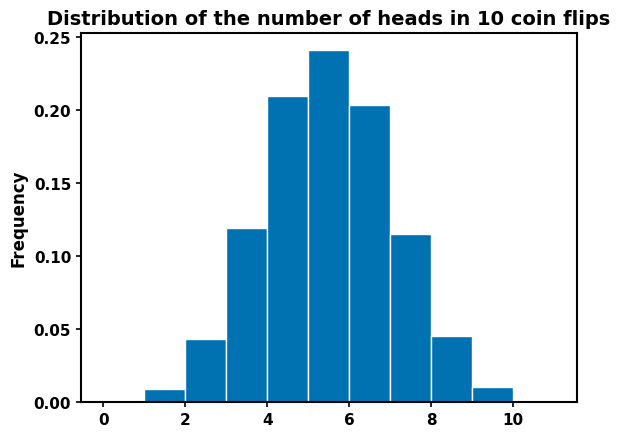

In [46]:
(bpd.DataFrame().assign(num_heads=heads_array)
 .plot(kind='hist', density=True, bins=np.arange(0, 12), ec='w', legend=False, 
       title = 'Distribution of the number of heads in 10 coin flips')
);


<center><img src='images/accumulate.jpg' width=60%></center> 

<!-- <span style="font-size:32px; font-weight:bold;">Dictionary</span>
<br>
<sub style="font-size:24px; font-weight:bold;">Definitions from Oxford Languages</sub>

---

<span style="font-size:48px; font-weight:bold;">ac·cu·mu·late</span>
<span style="font-size:24px;">/əˈkyo͞om(y)əˌlāt/</span>

<span style="font-size:32px; font-weight:bold;">verb</span>
<br>
<span style="font-size:32px;">
gather together or acquire an increasing number or quantity of.
</span>
<span style="font-size:32px;">
<br>
<br>
-"investigators have yet to accumulate enough evidence"
</span>

<span style="font-size:32px;">
<ul>
<li>gradually gather or acquire (a resulting whole).</li>
<span style="font-size:32px;">
"her goal was to accumulate a huge fortune"
</span>
</ul>
</span>

<span style="font-size:32px;">
<ul>
<li>gather; build up.</li>
<span style="font-size:32px;">
"the toxin accumulated in their bodies"
</span>
</ul>
</span>
-->

### The accumulator pattern

- To store our results, we'll typically use an `int` or an array.
- If using an `int`, we define an `int` variable (usually to `0`) before the loop, then use `+` to add to it inside the loop.
    - Think of this like using a tally.
- If using an array, we create an array (usually empty) before the loop, then use `np.append` to add to it inside the loop.
    - Think of this like writing the results on a piece of paper.
- This pattern – of repeatedly adding to an `int` or an array – is called the accumulator pattern.

### `for`-loops in DSC 10

- Almost every `for`-loop in DSC 10 will use the accumulator pattern.    
- Do **not** use `for`-loops to perform mathematical operations on every element of an array or Series.
    - Instead use DataFrame manipulations and built-in array or Series methods.
    
- Helpful video 🎥: [For Loops (and when not to use them) in DSC 10](https://www.youtube.com/watch?v=BlczSBT80fU).

## Summary and Break

### Summary

- `if`-statements allow us to run pieces of code depending on whether certain conditions are `True`.
- `for`-loops are used to repeat the execution of code for every element of a sequence.
    - Lists, arrays, and strings are examples of sequences.

### After the Break

- Probability. 
- A math lesson – no code!